In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Heart_disease_cleveland_new.csv")


In [2]:
print(df.shape)
print(df.columns)
df.head()

(303, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [5]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) |
            (df > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
age,0
sex,0
cp,23
trestbps,9
chol,5
fbs,45
restecg,0
thalach,1
exang,0
oldpeak,5


In [7]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) |
                 (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [8]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

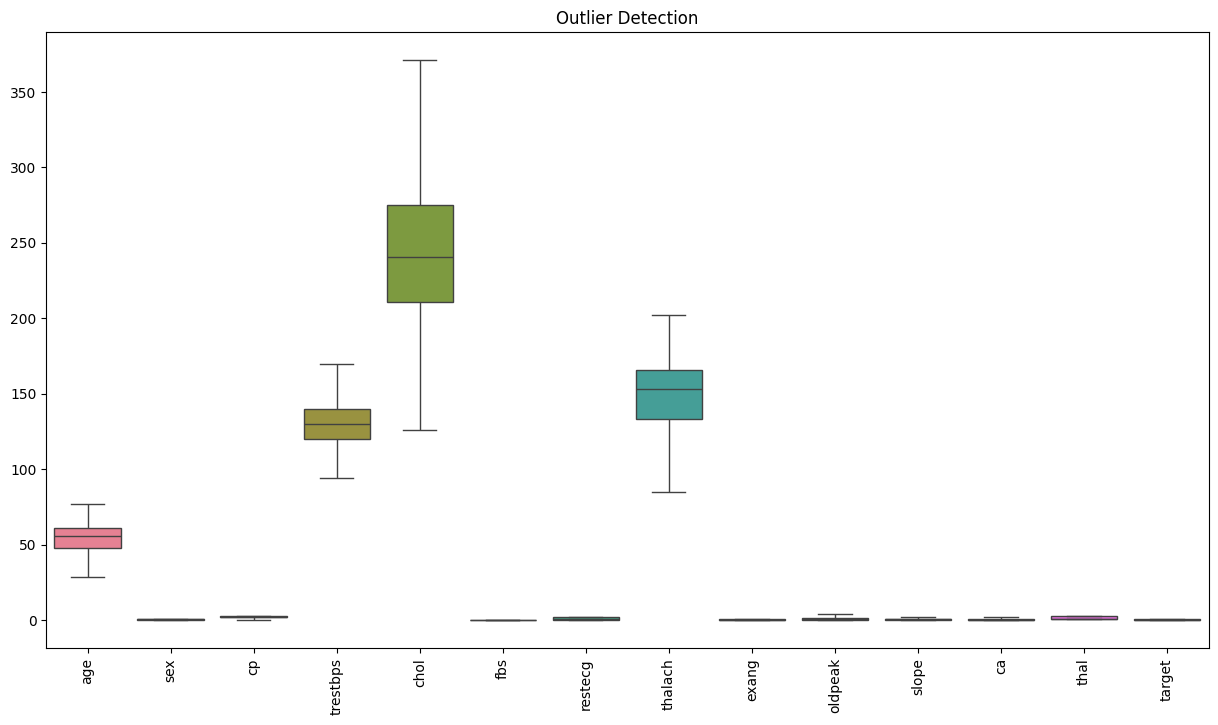

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [11]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [12]:
print("Preprocessed Feature Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

print("\nSample Data:")
print(X_scaled[:5]) # Using array slicing to show the first 5 rows of the NumPy array

Preprocessed Feature Shape: (303, 13)
Target Shape: (303,)

Sample Data:
        age       sex        cp  trestbps      chol  fbs   restecg   thalach  \
0  0.948726  0.686202 -1.930068  0.821446 -0.265040  0.0  1.016684  0.015306   
1  1.392002  0.686202  0.914342  1.723905  0.851214  0.0  1.016684 -1.835388   
2  1.392002  0.686202  0.914342 -0.682652 -0.349285  0.0  1.016684 -0.910041   
3 -1.932564  0.686202 -0.223422 -0.081013  0.093004  0.0 -0.996749  1.645679   
4 -1.489288 -1.457296 -1.361186 -0.081013 -0.875820  0.0  1.016684  0.984717   

      exang   oldpeak     slope        ca      thal  
0 -0.696631  1.150938  2.274579 -0.737100  0.176225  
1  1.435481  0.429108  0.649113  2.186216 -0.870759  
2  1.435481  1.421625  0.649113  1.601553  1.223208  
3 -0.696631  2.233684  2.274579 -0.737100 -0.870759  
4 -0.696631  0.338879 -0.976352 -0.737100 -0.870759  


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay



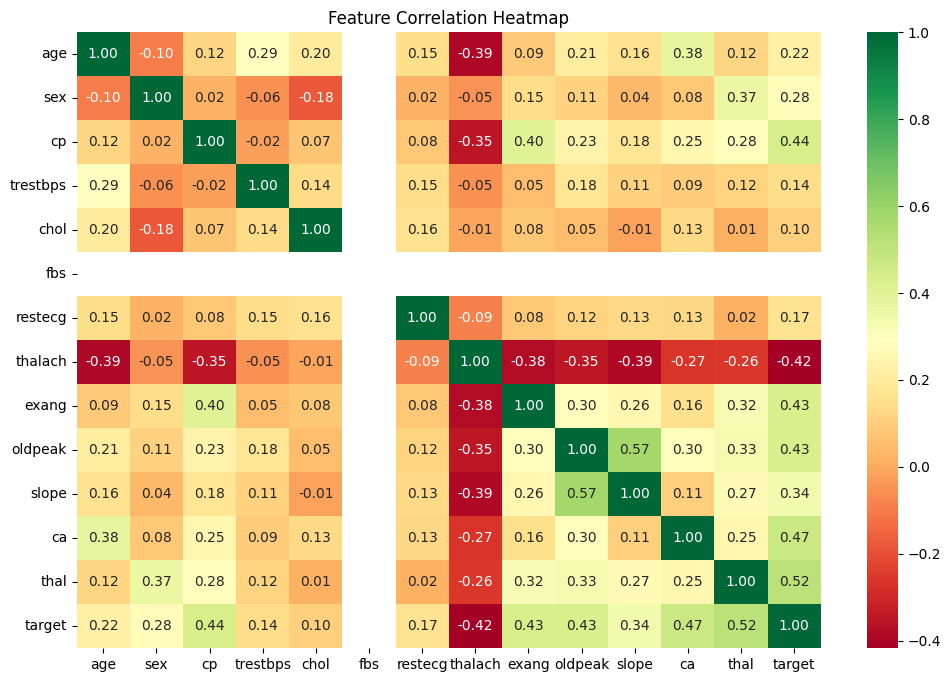

Top Features (Mutual Info): ['sex', 'cp', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Top Features (Chi-Square): ['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [15]:
# Feature Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Selection via Mutual Info and Chi-Square
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
chi_selector = SelectKBest(score_func=chi2, k=10)

mi_selector.fit(X, y)
chi_selector.fit(X, y)

print("Top Features (Mutual Info):", X.columns[mi_selector.get_support()].tolist())
print("Top Features (Chi-Square):", X.columns[chi_selector.get_support()].tolist())

In [16]:
# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
    print(classification_report(y_test, preds))


--- KNN ---
Accuracy: 0.90
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90        29
         1.0       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


--- Logistic Regression ---
Accuracy: 0.90
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        29
         1.0       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


--- Gradient Boosting ---
Accuracy: 0.87
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87        29
         1.0       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg  

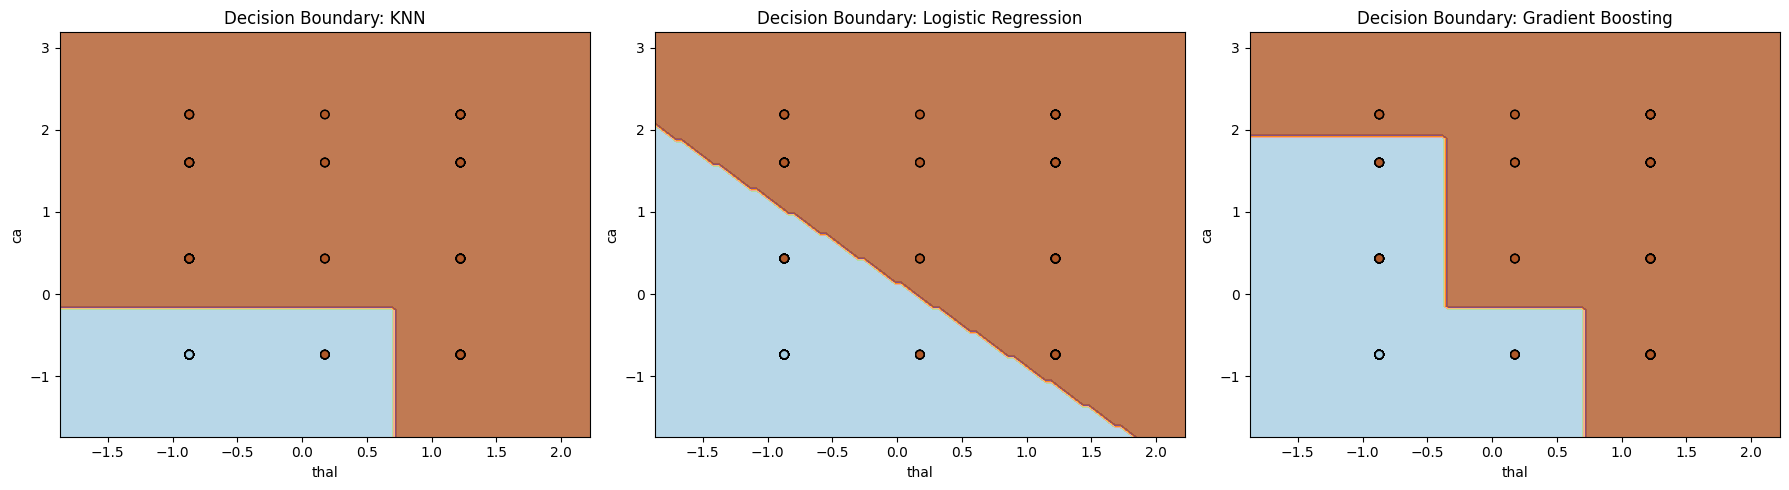

In [20]:
# Select two features for 2D visualization
features = ['thal', 'ca']
X_vis = X[features].values
X_vis_scaled = scaler.fit_transform(X_vis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_vis_scaled, y)
    DecisionBoundaryDisplay.from_estimator(
        model, X_vis_scaled, ax=ax, response_method="predict",
        cmap=plt.cm.Paired, alpha=0.8
    )
    ax.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(f"Decision Boundary: {name}")
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])

plt.tight_layout()
plt.show()

In [21]:
import pickle

# Save the best model (Logistic Regression) and the scaler
with open('heart_model.pkl', 'wb') as f:
    pickle.dump(models["Logistic Regression"], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [24]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.0 MB/s eta 0:00:00


In [25]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load model
with open('heart_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load scaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

st.title("Heart Disease Prediction App")

st.write("Enter patient details:")

age = st.number_input("Age")
sex = st.number_input("Sex (0=Female,1=Male)")
cp = st.number_input("Chest Pain Type")
trestbps = st.number_input("Resting Blood Pressure")
chol = st.number_input("Cholesterol")
fbs = st.number_input("Fasting Blood Sugar")
restecg = st.number_input("Rest ECG")
thalach = st.number_input("Max Heart Rate")
exang = st.number_input("Exercise Angina")
oldpeak = st.number_input("Oldpeak")
slope = st.number_input("Slope")
ca = st.number_input("CA")
thal = st.number_input("Thal")

if st.button("Predict"):
    input_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                            restecg, thalach, exang, oldpeak,
                            slope, ca, thal]])

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)

    if prediction[0] == 1:
        st.error("Heart Disease Detected")
    else:
        st.success("No Heart Disease")

Writing app.py
